# Analyse Experiment Results #

In [41]:
import os
import ast
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

## Analyse Dataset Selection Experiments with Negative Sampling & Smoothing Factor using Cold Start Setting ##

In [42]:
## util methods ##

def parse_cell(x):
    """
    Convert a cell into a Python object.
    Handles cases where the cell is already a list
    or stored as a string representation of a list.
    """
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        x = x.strip()
        try:
            return ast.literal_eval(x)
        except Exception:
            try:
                return json.loads(x)
            except Exception:
                return None
    return x


def avg_fold_metrics(fold_value):
    """
    fold_value should be a list of 10 sublists, each sublist like:
    [auc, aupr, precision, sensitivity, specificity]

    Returns:
    [avg_auc, avg_aupr, avg_precision, avg_sensitivity, avg_specificity]
    """
    fold_value = parse_cell(fold_value)

    if not fold_value:
        return [np.nan] * 5

    arr = np.array(fold_value, dtype=float)   # shape should be (10, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [43]:
EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_.csv'
EXP_0803_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0803.csv'
EXP_0903_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0903.csv'
EXP_1003_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_1003.csv'
EXP_1203_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_1203.csv' # VICTOR
EXP_1503_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1503.csv' # VICTOR
EXP_1703_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1703.csv' # VICTOR
EXP_2003_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_both_eval_2003.csv' # VICTOR

# preprocessed csv files name - for saving preprocessed results 
PREPROCESSED_EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_preprocessed_.csv'
PREPROCESSED_EXP_0803_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0803_full_preprocessed_.csv'
PREPROCESSED_EXP_0903_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0903_full_preprocessed_.csv'
PREPROCESSED_EXP_1203_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_1203_full_preprocessed_.csv'
PREPROCESSED_EXP_1503_PATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1503full_preprocessed_.csv'
PREPROCESSED_EXP_1703_PATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1703full_preprocessed_.csv'
PREPROCESSED_EXP_2003_PATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_both_eval_2003full_preprocessed_.csv'


In [44]:
exp_df = pd.read_csv(EXP_2003_VPATH)
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5
0,2003@j1,"{""fold1"": [[0.9739187844365155, 0.911556246152...","[[0.88070885532266, 0.8551065457191744, 0.9477...","[[0.526063391745667, 0.5469553193087026, 0.5, ...","[[0.5814919704861111, 0.5410742628622411, 0.45...","[[0.6878904529349804, 0.6843336534286761, 0.72...","[[0.512090713297866, 0.5201746255064316, 0.534..."
1,2003@j2,"{""fold1"": [[0.9837210239278021, 0.937808383442...","[[0.8383203100184233, 0.6885062511426832, 0.17...","[[0.9018220489188231, 0.8559763371227831, 0.84...","[[0.9285610385832213, 0.9000699673249206, 0.98...","[[0.9491449006305235, 0.8959257308963899, 0.90...","[[0.8725899554617909, 0.8371877830363665, 0.87..."


In [45]:
exp_df = exp_df.iloc[:, :].copy() # exclude experiments that still running
exp_df['exp']

0    2003@j1
1    2003@j2
Name: exp, dtype: object

In [46]:
exp_df.shape

(2, 7)

In [47]:
# add fold1_avg ... fold5_avg
for i in range(1, 6):
    exp_df[f"fold{i}_avg"] = exp_df[f"fold{i}"].apply(avg_fold_metrics)
exp_df.shape

(2, 12)

In [48]:
# add fold_statistics column; average over the 5 fold averages [auc, aupr, precision, sensitivity, specificity]
def compute_folds_statistics(row):
    '''
    creates folds statistic column which has the mean of each metric
    across all folds (and across its experiments) for auc, aupr,
    precision, sensitivity and specificity;
    [mean_auc_5_folds_experiments, mean_aupr_5_folds_experiments ...]
    # list order -> [auc, aupr, precision, sensitivity, specificity]
    '''
    fold_avgs = []
    for i in range(1, 6):
        val = row[f"fold{i}_avg"]
        val = parse_cell(val)
        if val is not None:
            fold_avgs.append(val)

    if not fold_avgs:
        return [np.nan] * 5

    arr = np.array(fold_avgs, dtype=float)   # shape (5, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [49]:
exp_df["folds_statistics"] = exp_df.apply(compute_folds_statistics, axis=1)
exp_df.shape

(2, 13)

In [50]:
# add AUC_statistics = [average_auc, variance_auc, std_auc]
# based on the 5 fold average AUCs: fold1_avg[0] ... fold5_avg[0]

def compute_auc_statistics(row):
    aucs = []
    for i in range(1, 6):
        fold_avg = parse_cell(row[f"fold{i}_avg"])
        if fold_avg is not None and len(fold_avg) > 0:
            aucs.append(float(fold_avg[0]))

    if not aucs:
        return [np.nan, np.nan, np.nan]

    aucs = np.array(aucs, dtype=float)
    return [
        float(np.mean(aucs)),
        float(np.var(aucs)),   # population variance
        float(np.std(aucs))    # population std
    ]

In [51]:
exp_df["AUC_statistics"] = exp_df.apply(compute_auc_statistics, axis=1)
exp_df.shape

(2, 14)

In [52]:
# round all columns (5 digits) ...
for col in [f"fold{i}_avg" for i in range(1, 6)] + ["folds_statistics", "AUC_statistics"]:
    exp_df[col] = exp_df[col].apply(
        lambda x: [round(v, 5) if pd.notna(v) else v for v in x] if isinstance(x, list) else x
    )
exp_df.shape

(2, 14)

In [53]:
exp_df.head(1)

,exp,val_res,fold1,fold2,fold3,fold4,fold5,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,2003@j1,"{""fold1"": [[0.9739187844365155, 0.911556246152...","[[0.88070885532266, 0.8551065457191744, 0.9477...","[[0.526063391745667, 0.5469553193087026, 0.5, ...","[[0.5814919704861111, 0.5410742628622411, 0.45...","[[0.6878904529349804, 0.6843336534286761, 0.72...","[[0.512090713297866, 0.5201746255064316, 0.534...","[0.81877, 0.78447, 0.8616, 0.17009, 0.97341]","[0.55464, 0.54418, 0.52123, 0.20034, 0.81684]","[0.5712, 0.54832, 0.53464, 0.11375, 0.91318]","[0.64069, 0.63363, 0.66291, 0.27785, 0.8591]","[0.52167, 0.52153, 0.53809, 0.24817, 0.78166]","[0.62139, 0.60643, 0.62369, 0.20204, 0.86884]","[0.62139, 0.01125, 0.10607]"


In [54]:
exp_df['exp']

0    2003@j1
1    2003@j2
Name: exp, dtype: object

In [55]:
def parse_if_string(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return x
    return x


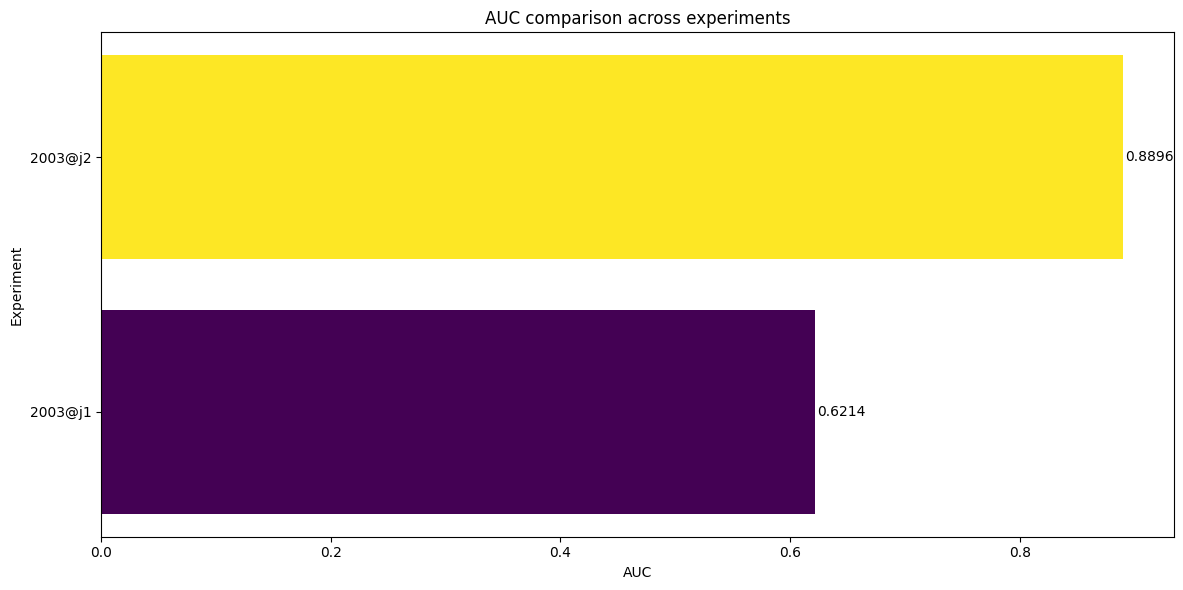

In [56]:

df = exp_df.copy()
df["folds_statistics"] = df["folds_statistics"].apply(parse_if_string)
df = df[df["folds_statistics"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 5)].copy()
metric_names = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]

for i, metric in enumerate(metric_names):
    df[metric] = df["folds_statistics"].apply(lambda x: x[i])


df["exp_clean"] = df["exp"].str.replace("dataset_", "", regex=False) # remove "dataset_" from experiment names
df = df.sort_values("AUC", ascending=True).reset_index(drop=True) # sort by AUC

# create colors according to AUC values
norm = mcolors.Normalize(vmin=df["AUC"].min(), vmax=df["AUC"].max())
colors = cm.viridis(norm(df["AUC"]))

# plotting pipeline ..
plt.figure(figsize=(12,6))
bars = plt.barh(df["exp_clean"], df["AUC"], color=colors)

plt.title("AUC comparison across experiments")
plt.xlabel("AUC")
plt.ylabel("Experiment")

for bar, value in zip(bars, df["AUC"]):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [35]:
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,2003@j1,"{""fold1"": [[0.9739187844365155, 0.911556246152...","[[0.88070885532266, 0.8551065457191744, 0.9477...","[[0.526063391745667, 0.5469553193087026, 0.5, ...","[[0.5814919704861111, 0.5410742628622411, 0.45...","[[0.6878904529349804, 0.6843336534286761, 0.72...","[[0.512090713297866, 0.5201746255064316, 0.534...","[0.81877, 0.78447, 0.8616, 0.17009, 0.97341]","[0.55464, 0.54418, 0.52123, 0.20034, 0.81684]","[0.5712, 0.54832, 0.53464, 0.11375, 0.91318]","[0.64069, 0.63363, 0.66291, 0.27785, 0.8591]","[0.52167, 0.52153, 0.53809, 0.24817, 0.78166]","[0.62139, 0.60643, 0.62369, 0.20204, 0.86884]","[0.62139, 0.01125, 0.10607]"
1,2003@j2,"{""fold1"": [[0.9837210239278021, 0.937808383442...","[[0.8383203100184233, 0.6885062511426832, 0.17...","[[0.9018220489188231, 0.8559763371227831, 0.84...","[[0.9285610385832213, 0.9000699673249206, 0.98...","[[0.9491449006305235, 0.8959257308963899, 0.90...","[[0.8725899554617909, 0.8371877830363665, 0.87...","[0.81196, 0.67581, 0.20919, 0.03064, 0.89434]","[0.88798, 0.83973, 0.78727, 0.16123, 0.94055]","[0.93682, 0.90418, 0.93308, 0.28738, 0.98327]","[0.94403, 0.89082, 0.90105, 0.69969, 0.9438]","[0.86712, 0.83377, 0.85215, 0.23776, 0.95541]","[0.88958, 0.82886, 0.73655, 0.28334, 0.94347]","[0.88958, 0.00235, 0.04843]"


In [34]:
arr = np.array(ast.literal_eval(exp_df.iloc[0, 2]), dtype=float)
arr

array([[0.88070886, 0.85510655, 0.94779116, 0.05446573, 0.99699977],
       [0.8239213 , 0.79013798, 0.88770865, 0.13501039, 0.98292176],
       [0.85333471, 0.82976187, 0.90045662, 0.22755597, 0.97484422],
       [0.85212443, 0.84182692, 0.91139241, 0.31571659, 0.96930533],
       [0.832838  , 0.79349952, 0.88068182, 0.14308793, 0.98061389],
       [0.80241233, 0.76031212, 0.81988473, 0.13131779, 0.97115163],
       [0.77814913, 0.70351534, 0.71629213, 0.11770136, 0.95338103],
       [0.71087336, 0.69571224, 0.8277439 , 0.12531733, 0.97392107],
       [0.84465077, 0.81754525, 0.87161773, 0.34941149, 0.9485345 ],
       [0.80865858, 0.75728942, 0.85242718, 0.10131549, 0.98246019]])

In [37]:
var0 = arr[:, 0].var()
print(var0)

0.0020699471142112858


In [57]:
exp_df.to_csv(PREPROCESSED_EXP_2003_PATH, index=False)

## Analyse first and last 5 Experiment Results ##

In [22]:
EXP_1503_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1503.csv' # VICTOR

In [39]:
exp_df = pd.read_csv(EXP_1503_VPATH)
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5
0,dataset_neg_fct_5_smoo_fct_0.9_1503@j2,"{""fold1"": [[0.9870957605022931, 0.947628508007...","[[0.6824265053651657, 0.6653360699265691, 0.86...","[[0.8487502252293029, 0.7935045520580875, 0.85...","[[0.9073943741272916, 0.8927620617085753, 0.94...","[[0.9668525379959322, 0.9519494170034655, 0.96...","[[0.9306467986568248, 0.9283141228187478, 0.96..."
1,dataset_neg_fct_5_smoo_fct_0.9_1503@j4,"{""fold1"": [[0.9882161502896648, 0.952728321791...","[[0.6783838183484806, 0.6620224861231838, 0.86...","[[0.8446870455001988, 0.7952797381935002, 0.86...","[[0.8950638484752939, 0.8768462983775632, 0.89...","[[0.9633692614192145, 0.9483151762604894, 0.95...","[[0.9235744334578224, 0.9238609428227462, 0.97..."
2,dataset_neg_fct_5_smoo_fct_0.9_1503@j5,"{""fold1"": [[0.9883505597281943, 0.952452278910...","[[0.730374727884913, 0.6926091143460115, 0.836...","[[0.8360985887929346, 0.7845121412963442, 0.85...","[[0.899679350029278, 0.8805304907317271, 0.890...","[[0.9647130156439735, 0.9497697359149242, 0.95...","[[0.9320016777132869, 0.9309840308815354, 0.96..."
3,dataset_neg_fct_5_smoo_fct_0.9_1503@j3,"{""fold1"": [[0.9887220524819077, 0.954915661273...","[[0.6868571929003444, 0.6953161318295789, 0.87...","[[0.8271329538273463, 0.7738090033175761, 0.83...","[[0.9049831651727399, 0.8872107798438864, 0.90...","[[0.9679387554093437, 0.9530693111775712, 0.95...","[[0.932203053538644, 0.930425346271282, 0.9659..."
4,dataset_neg_fct_5_smoo_fct_0.9_1503@j1,"{""fold1"": [[0.9880948084354368, 0.952343636811...","[[0.7238813739162155, 0.6913263422011363, 0.88...","[[0.8354459626408168, 0.7810172662725587, 0.87...","[[0.9019906197919012, 0.8844658963023292, 0.93...","[[0.9616815255696092, 0.9466335961397551, 0.95...","[[0.9264212215661504, 0.9252393370070784, 0.97..."
5,dataset_neg_fct_5_smoo_fct_0.9_1503@j6,"{""fold1"": [[0.9886094223505473, 0.955574571490...","[[0.7014828985436641, 0.6996680809228946, 0.88...","[[0.8593038884276537, 0.8040586509357075, 0.84...","[[0.8997659170758073, 0.8823510260755983, 0.90...","[[0.9659196477746596, 0.9514438772700716, 0.95...","[[0.9343914647592306, 0.9331078131621698, 0.96..."
6,dataset_neg_fct_5_smoo_fct_0.9_1503@j5_a,"{""fold1"": [[0.9878894606821279, 0.946923958226...","[[0.6988910086824541, 0.6398976402936377, 0.63...","[[0.81553569227082, 0.7614315531248477, 0.8184...","[[0.8904708684293502, 0.874967475270621, 0.934...","[[0.9665354943726014, 0.953223514298627, 0.963...","[[0.9333318933798137, 0.9300774467438241, 0.96..."
7,dataset_neg_fct_5_smoo_fct_0.9_1503@j1_a,"{""fold1"": [[0.9907854862697025, 0.961705364346...","[[0.7625489024196095, 0.7246311502236481, 0.89...","[[0.8254039686911873, 0.7684598090538375, 0.84...","[[0.9044074591234629, 0.8889397844141352, 0.92...","[[0.9692383884127787, 0.9546969739458493, 0.96...","[[0.9339888638013265, 0.930285980776724, 0.960..."
8,dataset_neg_fct_5_smoo_fct_0.9_1503@j3_a,"{""fold1"": [[0.9894392139536908, 0.953832569975...","[[0.7608237790380546, 0.7120432799219278, 0.73...","[[0.7988394117226141, 0.7401067254238999, 0.78...","[[0.9057182812711141, 0.8908439616187876, 0.93...","[[0.9729379885090259, 0.9585552279757699, 0.96...","[[0.9305289066483154, 0.9279480826557372, 0.96..."
9,dataset_neg_fct_5_smoo_fct_0.9_1503@j6_a,"{""fold1"": [[0.9876940691835249, 0.947326664320...","[[0.7089894616391311, 0.6547025714321113, 0.72...","[[0.823244353749238, 0.7719416572787667, 0.853...","[[0.8985532746272691, 0.882526640290105, 0.924...","[[0.9689103475287701, 0.9551114968200917, 0.96...","[[0.9179600211974552, 0.9187749406862491, 0.96..."


In [34]:
best_exp_df = exp_df[exp_df['exp'] == 'dataset_neg_fct_5_smoo_fct_0.9_1503@j6'].iloc[:,2:]
best_exp_df

,fold1,fold2,fold3,fold4,fold5
5,"[[0.7014828985436641, 0.6996680809228946, 0.88...","[[0.8593038884276537, 0.8040586509357075, 0.84...","[[0.8997659170758073, 0.8823510260755983, 0.90...","[[0.9659196477746596, 0.9514438772700716, 0.95...","[[0.9343914647592306, 0.9331078131621698, 0.96..."


In [43]:
best_exp_df.iloc[0, 0]

'[[0.7014828985436641, 0.6996680809228946, 0.8811881188118812, 0.14378029079159935, 0.9806138933764136], [0.743015193207149, 0.6751909444521739, 0.6906666666666667, 0.13947226709746904, 0.9375336564351104], [0.7457529457445942, 0.6793712289735393, 0.6984536082474226, 0.14593430263866453, 0.9369951534733441], [0.742062591037304, 0.7119505689946534, 0.8986784140969163, 0.1098546042003231, 0.9876144318793754], [0.721046766241867, 0.6892103004530203, 0.8297213622291022, 0.14431879375336565, 0.970382337102854], [0.7541074262661273, 0.7132626925287218, 0.8669201520912547, 0.12277867528271405, 0.9811523963381799], [0.7523973821274433, 0.7191472966940299, 0.8284182305630027, 0.16639741518578352, 0.9655358104469575], [0.747457770145361, 0.7250876637007182, 0.8858858858858859, 0.15885837372105546, 0.979536887452881], [0.7562170703408981, 0.7142922694640544, 0.8916666666666667, 0.11523963381798599, 0.9859989229940764], [0.7488363609263178, 0.6919993542106965, 0.8267326732673267, 0.089929994614970

In [45]:
lst = ast.literal_eval(best_exp_df.iloc[0, 0])

In [46]:
import pandas as pd
import numpy as np
import ast

# example: keep only one experiment, only fold columns
best_exp_df = exp_df[exp_df['exp'] == 'dataset_neg_fct_5_smoo_fct_0.9_1503@j6'].iloc[:, 2:].copy()

fold_cols = best_exp_df.columns.tolist()

# parse each fold cell from string -> python list
for fold in fold_cols:
    best_exp_df[fold] = best_exp_df[fold].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# take the single row
row = best_exp_df.iloc[0]

def avg_first_last_5(exp_list):
    arr = np.array(exp_list, dtype=float)   # expected shape: (10, 5)

    if arr.shape != (10, 5):
        raise ValueError(f"Expected shape (10, 5), got {arr.shape}")

    first5 = arr[:5].mean(axis=0)
    last5 = arr[5:].mean(axis=0)

    return {
        "AUC_first5": first5[0],
        "AUPR_first5": first5[1],
        "Precision_first5": first5[2],
        "Sensitivity_first5": first5[3],
        "Specificity_first5": first5[4],

        "AUC_last5": last5[0],
        "AUPR_last5": last5[1],
        "Precision_last5": last5[2],
        "Sensitivity_last5": last5[3],
        "Specificity_last5": last5[4],
    }

# per-fold summary
per_fold_results = {}

for fold in fold_cols:
    per_fold_results[fold] = avg_first_last_5(row[fold])

per_fold_df = pd.DataFrame(per_fold_results).T
per_fold_df.index.name = "fold"
per_fold_df = per_fold_df.reset_index()

# add differences: last5 - first5
metrics = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]
for metric in metrics:
    per_fold_df[f"{metric}_diff"] = per_fold_df[f"{metric}_last5"] - per_fold_df[f"{metric}_first5"]

display(per_fold_df)

,fold,AUC_first5,AUPR_first5,Precision_first5,Sensitivity_first5,Specificity_first5,AUC_last5,AUPR_last5,Precision_last5,Sensitivity_last5,Specificity_last5,AUC_diff,AUPR_diff,Precision_diff,Sensitivity_diff,Specificity_diff
0,fold1,0.730672,0.691078,0.799742,0.136672,0.962628,0.751803,0.712758,0.859925,0.130641,0.978675,0.021131,0.021680,0.060183,-0.006031,0.016047
1,fold2,0.828068,0.772900,0.847162,0.210399,0.962117,0.839071,0.779661,0.832028,0.204643,0.958960,0.011003,0.006761,-0.015135,-0.005757,-0.003157
2,fold3,0.897293,0.880890,0.922548,0.340772,0.971309,0.895084,0.881230,0.924892,0.347651,0.971812,-0.002208,0.000340,0.002344,0.006879,0.000503
3,fold4,0.968269,0.953529,0.959038,0.600690,0.974339,0.962743,0.948713,0.962637,0.600184,0.976730,-0.005525,-0.004816,0.003599,-0.000506,0.002391
4,fold5,0.934047,0.930669,0.965505,0.505547,0.981870,0.927043,0.926484,0.964528,0.509287,0.981173,-0.007004,-0.004185,-0.000977,0.003740,-0.000697


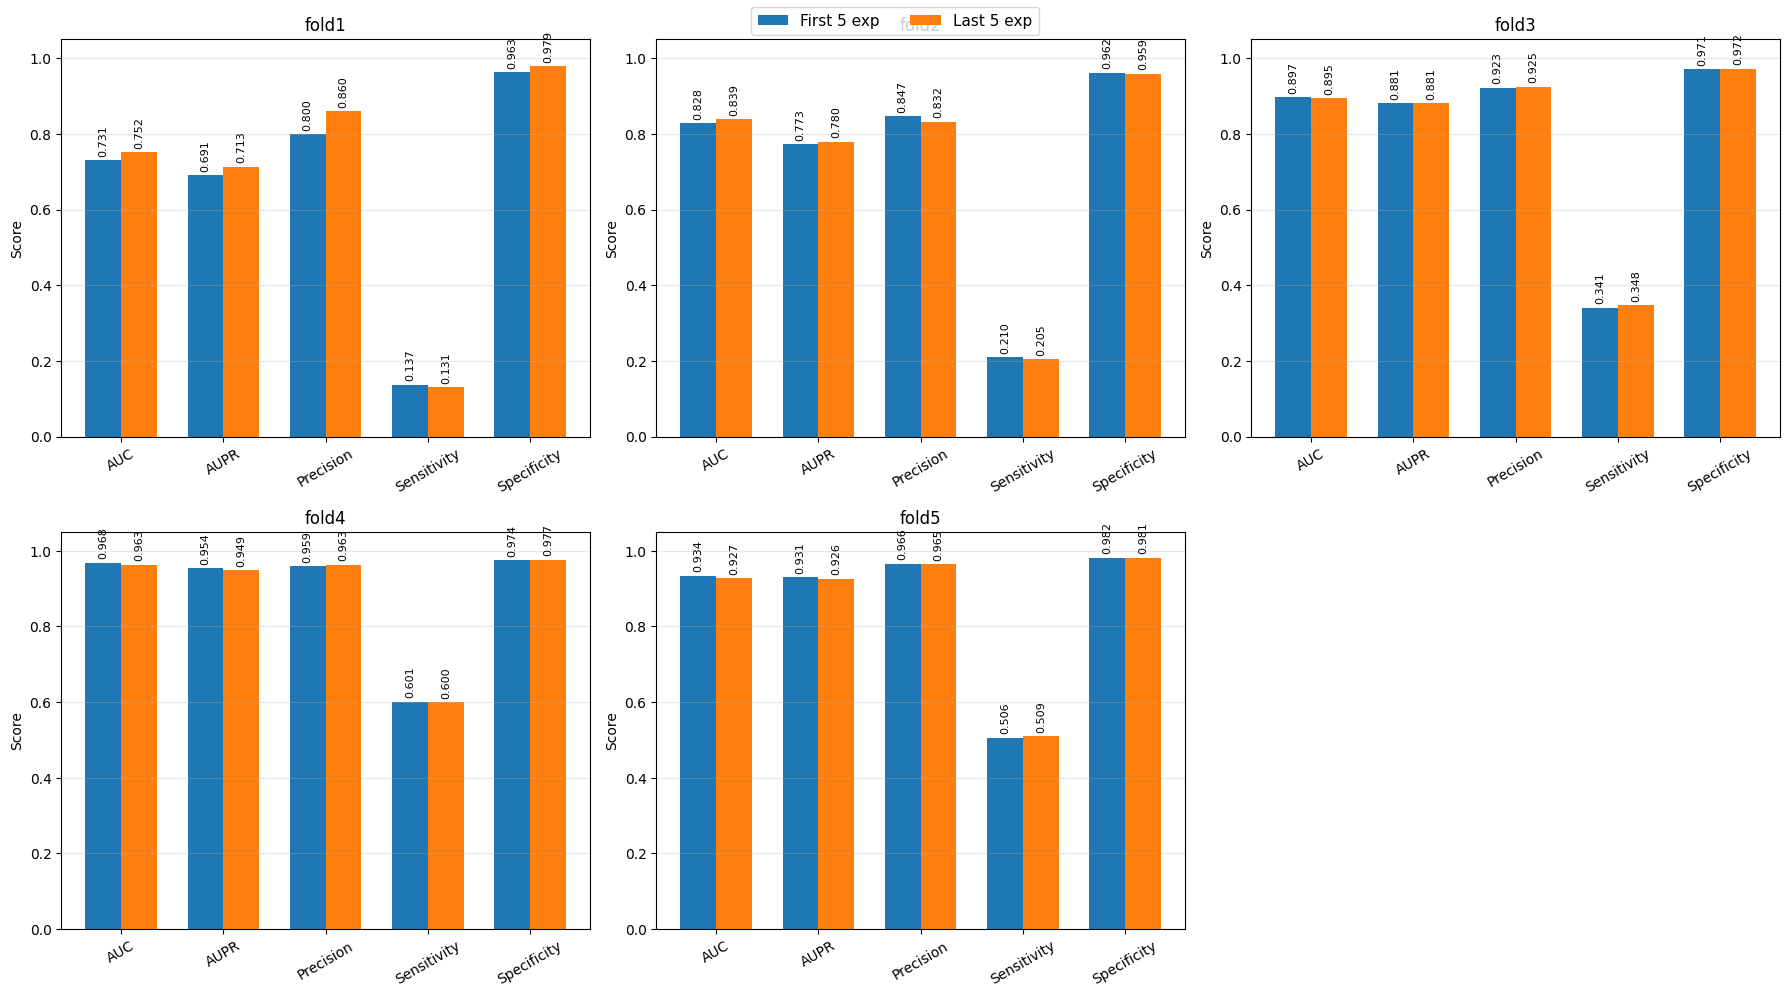

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# per_fold_df is expected to contain columns like:
# fold, AUC_first5, AUC_last5, AUPR_first5, AUPR_last5, ...

metrics = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]

n_folds = len(per_fold_df)
ncols = 3
nrows = int(np.ceil(n_folds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10))
axes = np.array(axes).reshape(-1)

x = np.arange(len(metrics))
bar_width = 0.35

for i, (_, row) in enumerate(per_fold_df.iterrows()):
    ax = axes[i]

    first_vals = [row[f"{m}_first5"] for m in metrics]
    last_vals  = [row[f"{m}_last5"] for m in metrics]

    ax.bar(x - bar_width/2, first_vals, width=bar_width, label="First 5 exp")
    ax.bar(x + bar_width/2, last_vals,  width=bar_width, label="Last 5 exp")

    ax.set_title(f"{row['fold']}")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=30)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

    # add values above bars
    for xi, v in zip(x - bar_width/2, first_vals):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)

    for xi, v in zip(x + bar_width/2, last_vals):
        ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)

# hide unused subplots if fewer than grid slots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=11)

fig.suptitle("First 5 vs Last 5 Experiments per Fold", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [54]:
import numpy as np
import ast

fold_cols = best_exp_df.columns.tolist()

# make sure parsed
for fold in fold_cols:
    best_exp_df[fold] = best_exp_df[fold].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

row = best_exp_df.iloc[0]

first5_fold_avgs = []
last5_fold_avgs = []

for fold in fold_cols:
    arr = np.array(row[fold], dtype=float)

    first5_avg = np.round(arr[:5].mean(axis=0), 5)
    last5_avg  = np.round(arr[5:10].mean(axis=0), 5)

    first5_fold_avgs.append(first5_avg)
    last5_fold_avgs.append(last5_avg)

# average across folds
first5_all_folds_avg = np.round(np.mean(first5_fold_avgs, axis=0), 5)
last5_all_folds_avg  = np.round(np.mean(last5_fold_avgs, axis=0), 5)

print("First 5 (AUC, AUPR, Precision, Sensitivity, Specificity):", first5_all_folds_avg.tolist())
print("Last 5 (AUC, AUPR, Precision, Sensitivity, Specificity):", last5_all_folds_avg.tolist())

First 5 (AUC, AUPR, Precision, Sensitivity, Specificity): [0.87167, 0.84581, 0.8988, 0.35882, 0.97045]
Last 5 (AUC, AUPR, Precision, Sensitivity, Specificity): [0.87515, 0.84977, 0.9088, 0.35848, 0.97347]
